<a href="https://colab.research.google.com/github/linyuan-zhang/Macroeconomics_Visualizations/blob/main/304_Phillip's_Curve_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook is based on an Excel homework for Professor Erin Cottle Hunt's Intermediate Macroeconomics.

This notebook plots a joined result of Phillip's Curve (the relationship between Unemployment and Inflation) and Okun's Law (the relationship between Unemployment and Short-Run Real GDP). The plots are relationships between (United States') Short-Run Real GDP and Inflation, with the former on the $x$-axis and the latter $y$ axis. The plots demonstrates that there is a positive relationship between Short-Run Real GDP and Inflation. The data used are real GDP, real potential GDP and inflation of the United States, from 1971 onwards.

There is a tutorial in R and a tutorial in Python, providing the same computations and visualizations.

Load Python libraries.

In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

## Data

To calculate Short-Run Real GDP, we need Real GDP and Real Potentional GDP. Short-Run Real GDP, aka. the output gap, is the percentage difference between Real GDP and Real Potential GDP.

The data for United States' Real GDP and Real Potential GDP can be found in the FRED database.

The series' codes in the FRED database are `GDPC1` and `GDPPOT`, respectively.

To obtain the URLs from which to load the CSV format data, find the page of the data series, find "Download", find "CSV (data)", and copy the link address for "CSV (data)".

When loading, set the end year of the data series to be `2099` so that the data is always up-to-date.

The data are quarterly. The current Real GDP series starts at the first quarter of `1976` and ends at the second quarter of `2026`. The current Real Potential GDP series starts at the first quarter of `1976` and ends at the fourth quarter of `2036`.

In [2]:
rgdp = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=GDPC1&scale=left&cosd=1976-01-01&coed=2099-12-31&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Quarterly&fam=avg&fgst=lin&fgsnd=2099-12-31&line_index=1&transformation=lin&nd=1976-01-01")

In [3]:
rgdppot = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=GDPPOT&scale=left&cosd=1976-01-01&coed=2099-12-31&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Quarterly&fam=avg&fgst=lin&fgsnd=2099-12-31&line_index=1&transformation=lin&nd=1976-01-01")

We also need data for United States' inflation. The series' code is `CPALTT01USM661S`.

The data is monthly. The series starts at January `1976` and ends at March `2024`.

In [4]:
inflation = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=CPALTT01USM657N&scale=left&cosd=1976-01-01&coed=2099-12-31&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Monthly&fam=avg&fgst=lin&fgsnd=2099-12-31&line_index=1&transformation=lin&nd=1976-01-01")

### Data Cleaning

To document the relationships, we `inner` `merge` all requisite data into one dataset.

When we `merge` two datasets containing different series, the `merge` function in `pandas`, when `how` set to `inner` and `on` set to `observation_date`, keeps only entries with the same date. Therefore, if we `merge` the three series, the start time will be the first quarter of `1976` and the end time will be the first quarter of `2024`. All data will be quarterly.

In [5]:
df = pd.merge(rgdp, rgdppot, on = "observation_date", how = "inner")

df = pd.merge(df, inflation, on = "observation_date", how = "inner")

df.columns = ["quarter", "rgdp", "rgdppot", "inflation"]

Because we eventually want to filter the data by `year`, we use the following code to separate the `year` and `quarter` of the dates.

In [6]:
df["quarter"] = pd.to_datetime(df["quarter"])
df["year"] = df["quarter"].dt.year

### Calculation

Calculate Short-Run Real GDP.

In [7]:
df["rgdpsh"] = (df["rgdp"] - df["rgdppot"])/((df["rgdp"] + df["rgdppot"])/2) * 100

### Filtering

We want to create the Short-Run Real GDP versus Inflation plots for the following times:

A. Until 2008 (the year of Global Financial Crisis), including 2008;

B. After 2008 and including 2020 (the year COVID-19 took place), excluding 2008;

C. After 2008 and excluding 2020.

Therefore, we filter the dataset we have created into three separate datasets.

In [8]:
df_phillips_1976_2008 = df.query("year <= 2008")
df_phillips_2009_ = df.query("year > 2008")
df_phillips_2009_no_2020 = df.query("(year > 2008) and (year != 2020)")

## Visualization

Plot the relationship between Short-Run Real GDP and Inflation (most early-most recent).

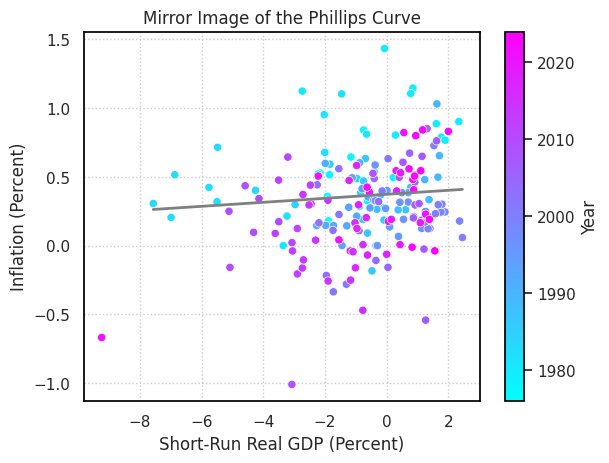

In [9]:
sns.set_theme(
    context = "notebook",
    style = "whitegrid",
    font = "sans-serif",
    rc = {
        "grid.linestyle": ":",
        "axes.edgecolor": "black",
    },
)

ax = sns.scatterplot(
    data = df,
    x = "rgdpsh",
    y = "inflation",
    hue = "quarter",
    palette = "cool",
    legend = False
)

norm = mpl.colors.Normalize(
    vmin = df["year"].min(),
    vmax = df["year"].max()
)

sm = mpl.cm.ScalarMappable(
    norm = norm,
    cmap = "cool"
)

cbar = ax.figure.colorbar(sm, ax = ax)

cbar.set_label("Year")

sns.regplot(
    data = df_phillips_1976_2008,
    x = "rgdpsh",
    y = "inflation",
    ax = ax,
    scatter = False,
    line_kws = {"color": "grey", "linewidth": 2},
    ci = None
)

ax.set(
    title = "Mirror Image of the Phillips Curve",
    xlabel = "Short-Run Real GDP (Percent)",
    ylabel = "Inflation (Percent)",
)

plt.show()

Plot the relationship between Short-Run Real GDP and Inflation (1971-2008, inclusive).

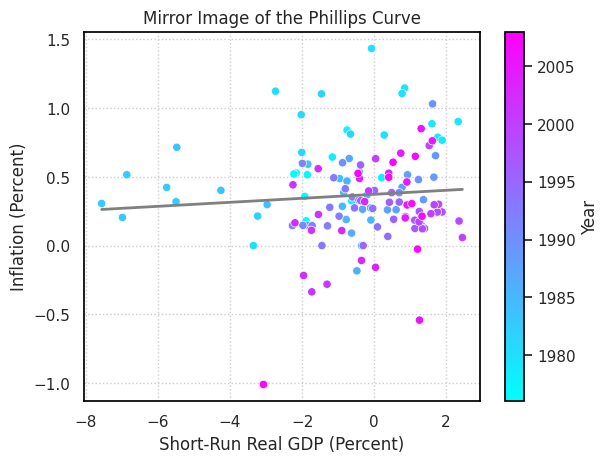

In [10]:
sns.set_theme(
    context = "notebook",
    style = "whitegrid",
    font = "sans-serif",
    rc = {
        "grid.linestyle": ":",
        "axes.edgecolor": "black",
    },
)

ax = sns.scatterplot(
    data = df_phillips_1976_2008,
    x = "rgdpsh",
    y = "inflation",
    hue = "quarter",
    palette = "cool",
    legend = False
)

norm = mpl.colors.Normalize(
    vmin = df_phillips_1976_2008["year"].min(),
    vmax = df_phillips_1976_2008["year"].max()
)

sm = mpl.cm.ScalarMappable(
    norm = norm,
    cmap = "cool"
)

cbar = ax.figure.colorbar(sm, ax = ax)

cbar.set_label("Year")

sns.regplot(
    data = df_phillips_1976_2008,
    x = "rgdpsh",
    y = "inflation",
    ax = ax,
    scatter = False,
    line_kws = {"color": "grey", "linewidth": 2},
    ci = None
)

ax.set(
    title = "Mirror Image of the Phillips Curve",
    xlabel = "Short-Run Real GDP (Percent)",
    ylabel = "Inflation (Percent)",
)

plt.show()

Plot the relationship between Short-Run Real GDP and Inflation (2009-most recent, including 2020).

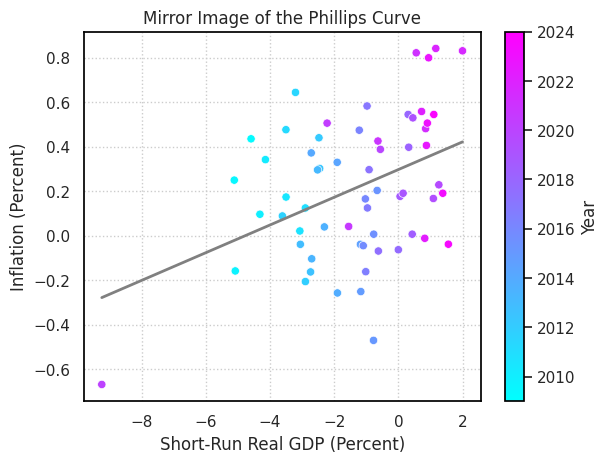

In [11]:
ax = sns.scatterplot(
    data = df_phillips_2009_,
    x = "rgdpsh",
    y = "inflation",
    hue = "quarter",
    palette = "cool",
    legend = False
)

norm = mpl.colors.Normalize(
    vmin = df_phillips_2009_["year"].min(),
    vmax = df_phillips_2009_["year"].max()
)

sm = mpl.cm.ScalarMappable(
    norm = norm,
    cmap = "cool"
)

cbar = ax.figure.colorbar(sm, ax = ax)

cbar.set_label("Year")

sns.regplot(
    data = df_phillips_2009_,
    x = "rgdpsh",
    y = "inflation",
    ax = ax,
    scatter = False,
    line_kws = {"color": "grey", "linewidth": 2},
    ci = None
)

ax.set(
    title = "Mirror Image of the Phillips Curve",
    xlabel = "Short-Run Real GDP (Percent)",
    ylabel = "Inflation (Percent)",
)

plt.show()

Plot the relationship between Short-Run Real GDP and Inflation (2009-most recent, excluding 2020).

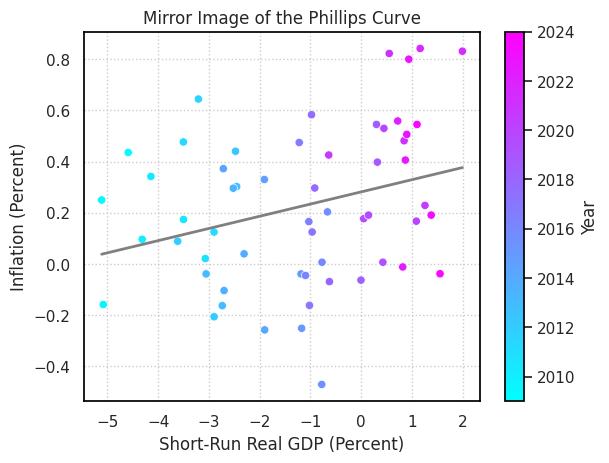

In [12]:
ax = sns.scatterplot(
    data = df_phillips_2009_no_2020,
    x = "rgdpsh",
    y = "inflation",
    hue = "quarter",
    palette = "cool",
    legend = False
)

norm = mpl.colors.Normalize(
    vmin = df_phillips_2009_no_2020["year"].min(),
    vmax = df_phillips_2009_no_2020["year"].max()
)

sm = mpl.cm.ScalarMappable(
    norm = norm,
    cmap = "cool"
)

cbar = ax.figure.colorbar(sm, ax = ax)

cbar.set_label("Year")

sns.regplot(
    data = df_phillips_2009_no_2020,
    x = "rgdpsh",
    y = "inflation",
    ax = ax,
    scatter = False,
    line_kws = {"color": "grey", "linewidth": 2},
    ci = None
)

ax.set(
    title = "Mirror Image of the Phillips Curve",
    xlabel = "Short-Run Real GDP (Percent)",
    ylabel = "Inflation (Percent)",
)

plt.show()

## Conclusion

According to Phillip's Curve, there is a negative relationship between Unemployment and Inflation. According to Okun's Law, there is a negative relationship between Unemployment and Short-Run Real GDP. Therefore, there should be a positive relationship between Short-Run Real GDP and Inflation.

In the four plots, we observe a positive relationship between Short-Run Real GDP. This observation verifies the theory.

The following is the conclusion from the second plot:

Until 2008, the inflation was stable, as is demonstrated by the almost-flat line. Short-run real GDP was growing, because we see the blue dots clustered on the left and the purple dots clustered on the right. There are two outliers at the bottom. Their pink color indicates that they were of a time very close to 2008. These two ouliers represents that during the Global Financial Crisis, there was much deflation.

The following is the conclusion from the fourth plot:

After 2008, the inflation has in general risen steadily, and the relationship between short-run real GDP and inflation is more positive than until 2008. Similar to until 2008, short-run real GDP grows, because of the positions of blue dots and purple dots.

The third plot adds the data points representing the COVID year into the third plot. The COVID year is represented by some outliers at the bottom-left of the plot. During the COVID year, there was negative short-run real GDP because production was paused. There was also deflation.

The first plot exhibits all data from 1971. It is more similar to the second plot.